# QC audit — sequencing coverage vs usable panel k-mers

**Cohort:** 2,168 evolved GrENE-Net samples, after the `per_founder` rerun.

**Motivation.** Five samples produced an *all-NaN* founder haplotype (`h`) vector in the
per-founder rerun. A first guess was "just low sequencing depth". That turned out to be
**wrong**: at ~1× depth (which is normal in this cohort — nothing is below 1×) these
samples match the 231-founder panel at only **~0.7 %** of Chr1 panel k-mers, versus **~10 %**
for other 1× samples. In other words their reads are largely **not from the panel founders** —
consistent with contamination, a mislabel, or off-panel DNA.

This notebook visualizes **sequencing coverage vs the usable-panel-k-mer fraction** and
identifies the anomalous (contamination-suspect) samples.

**Key quantities**
- `seq_depth` — Table_S5 weighted-mean coverage (sequencing depth, ×).
- `nzfrac_chr1` — fraction of the Chr1 founder-panel k-mers seen with nonzero count in the
  sample's reads (the *usable panel data* fraction).
- QC rule applied downstream: **drop samples with `nzfrac_chr1 < 0.10`** (17 samples).
- The 5 "dead/contaminated" libraries sit at `nzfrac < 0.01`.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

import os
# resolve repo root robustly (nbconvert may set cwd to the notebook dir)
def _find(relpath):
    for base in ['.', '..', '../..', '../../..',
                 '/global/scratch/users/tbellg/kmate']:
        p = os.path.join(base, relpath)
        if os.path.exists(p):
            return p
    return relpath
CSV = _find('results/grenenet_gea/qc_coverage_audit.csv')
EXCL = _find('data/qc_lowcov_exclude.txt')
print("CSV :", os.path.abspath(CSV))
print("EXCL:", os.path.abspath(EXCL))

df = pd.read_csv(CSV, index_col=0)
df.index.name = 'sample_id'

# panelcov_chr1 may be entirely/mostly NaN -> handle gracefully
have_panelcov = ('panelcov_chr1' in df.columns) and (df['panelcov_chr1'].isna().mean() <= 0.50)
print(f"n samples            : {len(df)}")
print(f"columns              : {list(df.columns)}")
if 'panelcov_chr1' in df.columns:
    print(f"panelcov_chr1 NaN%%   : {df['panelcov_chr1'].isna().mean()*100:.1f}  ->  use it: {have_panelcov}")

# excluded flag (guard if missing)
if 'excluded_nzfrac_lt_0.10' in df.columns:
    df['excluded'] = df['excluded_nzfrac_lt_0.10'].astype(bool)
else:
    df['excluded'] = df['nzfrac_chr1'] < 0.10

QC_CUT = 0.10
DEAD_CUT = 0.01

# read the curated exclude list
excl_ids = []
with open(EXCL) as fh:
    for line in fh:
        line = line.rstrip('\n')
        if not line or line.startswith('#'):
            continue
        excl_ids.append(line.split('\t')[0])
excl_ids = [s for s in excl_ids if s in df.index]

dead_ids = ['MLFH131020200221','MLFH131220200205','MLFH520720190322',
            'MLFH130820200221','MLFH130820200205']
dead_ids = [s for s in dead_ids if s in df.index]

print(f"excluded (flag)      : {int(df['excluded'].sum())}")
print(f"exclude-file ids     : {len(excl_ids)}")
print(f"dead ids present     : {len(dead_ids)}")
print(f"seq_depth   min/med/max: {df.seq_depth.min():.2f} / {df.seq_depth.median():.2f} / {df.seq_depth.max():.2f}")
print(f"nzfrac_chr1 min/med/max: {df.nzfrac_chr1.min():.4f} / {df.nzfrac_chr1.median():.4f} / {df.nzfrac_chr1.max():.4f}")

CSV : /global/scratch/users/tbellg/kmate/results/grenenet_gea/qc_coverage_audit.csv
EXCL: /global/scratch/users/tbellg/kmate/data/qc_lowcov_exclude.txt
n samples            : 2168
columns              : ['seq_depth', 'nzfrac_chr1', 'panelcov_chr1', 'excluded_nzfrac_lt_0.10']
panelcov_chr1 NaN%%   : 100.0  ->  use it: False
excluded (flag)      : 17
exclude-file ids     : 17
dead ids present     : 5
seq_depth   min/med/max: 1.03 / 6.68 / 27.94
nzfrac_chr1 min/med/max: 0.0069 / 0.2659 / 0.5250


## 1. Distribution of sequencing coverage (Table_S5 depth)

Sequencing depth across the cohort. **Even the lowest-depth sample is ~1× — nothing is
below 1×**, so depth is not the thing that separates the dead libraries.

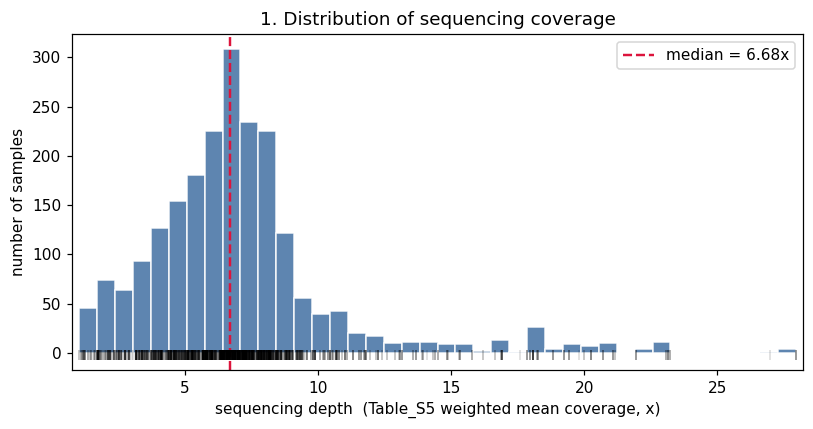

seq_depth: min=1.03x  median=6.68x  max=27.94x  (n=2168)
No sample is below 1x coverage.


In [2]:
fig, ax = plt.subplots(figsize=(7.5, 4))
d = df['seq_depth'].dropna()
ax.hist(d, bins=40, color='#4c78a8', edgecolor='white', alpha=0.9)
med = d.median()
ax.axvline(med, color='crimson', ls='--', lw=1.6, label=f'median = {med:.2f}x')
# rug
ax.plot(d, np.full_like(d, -2, dtype=float), '|', color='k', alpha=0.15, ms=6, clip_on=False)
ax.set_xlabel('sequencing depth  (Table_S5 weighted mean coverage, x)')
ax.set_ylabel('number of samples')
ax.set_title('1. Distribution of sequencing coverage')
ax.legend()
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

print(f"seq_depth: min={d.min():.2f}x  median={d.median():.2f}x  max={d.max():.2f}x  (n={len(d)})")
print("No sample is below 1x coverage.")

## 2. Distribution of usable panel k-mers (`nzfrac_chr1`)

Fraction of Chr1 panel k-mers observed in each sample. The main body starts around
**~0.06** and rises to ~0.53. A **tiny "dead" cluster near ~0.007–0.009 (5 samples)** sits
separated from the main body by a clear gap. The **`nzfrac < 0.10` QC cut** (dashed line)
removes 17 samples in total.

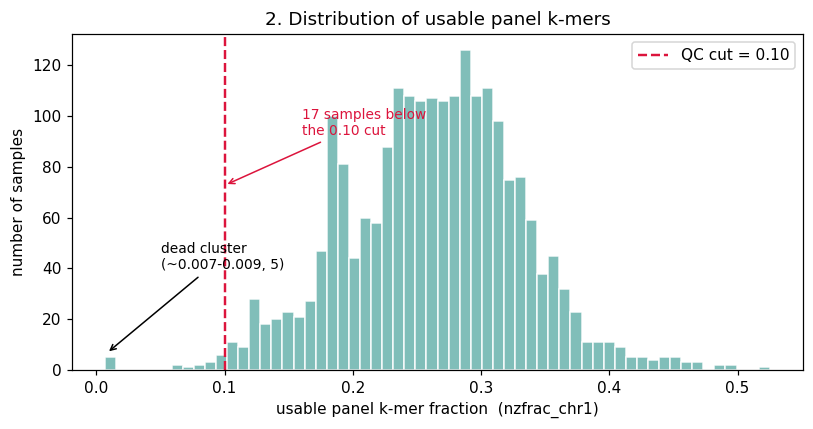

nzfrac < 0.10 (QC cut) : 17 samples
nzfrac < 0.01 (dead)   : 5 samples
main body (nzfrac>=0.10): starts at 0.100, median 0.266
gap: max dead=0.0088  ->  next sample up=0.0592


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4))
v = df['nzfrac_chr1'].dropna()
ax.hist(v, bins=60, color='#72b7b2', edgecolor='white', alpha=0.9)
ax.axvline(QC_CUT, color='crimson', ls='--', lw=1.6, label=f'QC cut = {QC_CUT:.2f}')
n_below = int((v < QC_CUT).sum())
n_dead  = int((v < DEAD_CUT).sum())
ax.annotate(f'{n_below} samples below\nthe 0.10 cut',
            xy=(QC_CUT, ax.get_ylim()[1]*0.55),
            xytext=(QC_CUT+0.06, ax.get_ylim()[1]*0.7),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            color='crimson', fontsize=9)
ax.annotate(f'dead cluster\n(~0.007-0.009, {n_dead})',
            xy=(0.008, ax.get_ylim()[1]*0.05),
            xytext=(0.05, ax.get_ylim()[1]*0.30),
            arrowprops=dict(arrowstyle='->', color='black'),
            color='black', fontsize=9)
ax.set_xlabel('usable panel k-mer fraction  (nzfrac_chr1)')
ax.set_ylabel('number of samples')
ax.set_title('2. Distribution of usable panel k-mers')
ax.legend()
plt.tight_layout()
plt.show()

print(f"nzfrac < 0.10 (QC cut) : {n_below} samples")
print(f"nzfrac < 0.01 (dead)   : {n_dead} samples")
body = v[v >= QC_CUT]
print(f"main body (nzfrac>=0.10): starts at {body.min():.3f}, median {body.median():.3f}")
print(f"gap: max dead={v[v<DEAD_CUT].max():.4f}  ->  next sample up={v[v>=DEAD_CUT].min():.4f}")

## 3. THE KEY PLOT — coverage vs usable k-mers (contamination scatter)

Each point is one sample: sequencing **depth** (x) vs **usable panel k-mer fraction** (y).

- Most samples follow a rising **depth → usable-k-mers** trend (fit on the *non-excluded*
  samples, drawn as the dashed line).
- The **contaminated / dead libraries (black)** have perfectly normal — even fairly high —
  sequencing depth, yet almost no panel k-mers. They sit **far below the trend**: their reads
  carry DNA that is *not* from the 231 panel founders.
- We quantify this with a **residual** = `nzfrac − predicted(seq_depth)`; the flagged samples
  are the extreme negative residuals.

fit on 2151 non-excluded samples
  nzfrac ~ 0.01024 * depth + 0.1920
  Pearson r (non-excluded)      = 0.5710
  Pearson r (all samples)       = 0.5675


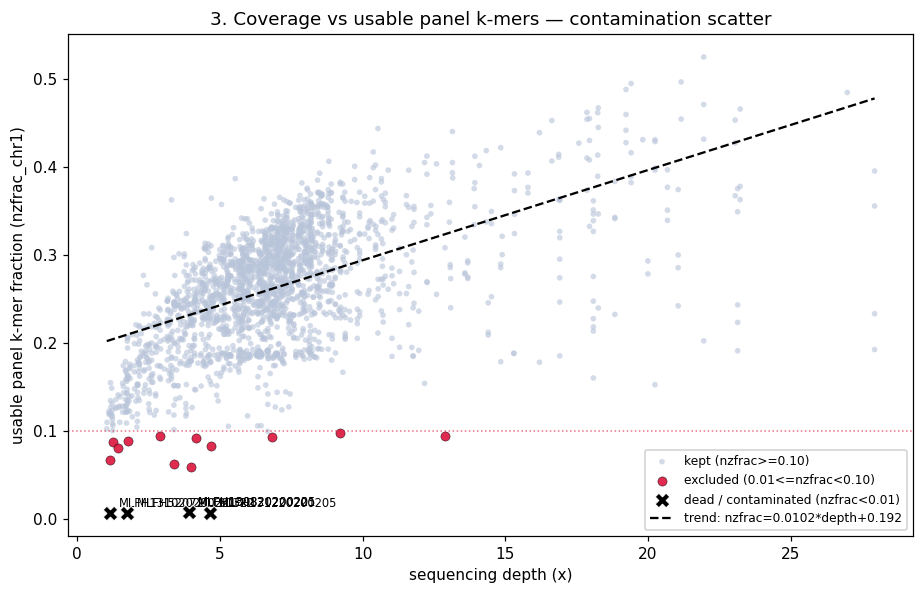

In [4]:
# --- fit the depth -> nzfrac trend on NON-excluded samples (robust to NaN) ---
fitmask = (~df['excluded']) & df['seq_depth'].notna() & df['nzfrac_chr1'].notna()
x_fit = df.loc[fitmask, 'seq_depth'].values
y_fit = df.loc[fitmask, 'nzfrac_chr1'].values
slope, intercept = np.polyfit(x_fit, y_fit, 1)
corr = np.corrcoef(x_fit, y_fit)[0, 1]
print(f"fit on {fitmask.sum()} non-excluded samples")
print(f"  nzfrac ~ {slope:.5f} * depth + {intercept:.4f}")
print(f"  Pearson r (non-excluded)      = {corr:.4f}")
print(f"  Pearson r (all samples)       = {df.seq_depth.corr(df.nzfrac_chr1):.4f}")

# residual for every sample
df['pred_nzfrac'] = slope * df['seq_depth'] + intercept
df['residual'] = df['nzfrac_chr1'] - df['pred_nzfrac']

fig, ax = plt.subplots(figsize=(8.5, 5.5))
is_dead = df.index.isin(dead_ids)
is_excl = df['excluded'].values & ~is_dead
is_ok   = ~df['excluded'].values

ax.scatter(df.loc[is_ok,'seq_depth'], df.loc[is_ok,'nzfrac_chr1'],
           s=14, c='#b8c4d9', alpha=0.6, edgecolor='none', label='kept (nzfrac>=0.10)')
ax.scatter(df.loc[is_excl,'seq_depth'], df.loc[is_excl,'nzfrac_chr1'],
           s=36, c='crimson', alpha=0.9, edgecolor='k', linewidth=0.3,
           label='excluded (0.01<=nzfrac<0.10)')
ax.scatter(df.loc[is_dead,'seq_depth'], df.loc[is_dead,'nzfrac_chr1'],
           s=90, c='black', marker='X', edgecolor='white', linewidth=0.6,
           label='dead / contaminated (nzfrac<0.01)', zorder=5)

# trend line
xs = np.linspace(df.seq_depth.min(), df.seq_depth.max(), 100)
ax.plot(xs, slope*xs + intercept, 'k--', lw=1.5,
        label=f'trend: nzfrac={slope:.4f}*depth+{intercept:.3f}')
ax.axhline(QC_CUT, color='crimson', ls=':', lw=1, alpha=0.6)

# annotate the 5 dead with IDs
for sid in dead_ids:
    ax.annotate(sid, (df.loc[sid,'seq_depth'], df.loc[sid,'nzfrac_chr1']),
                xytext=(6, 4), textcoords='offset points', fontsize=7.5, color='black')

ax.set_xlabel('sequencing depth (x)')
ax.set_ylabel('usable panel k-mer fraction (nzfrac_chr1)')
ax.set_title('3. Coverage vs usable panel k-mers — contamination scatter')
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

**Interpretation.** Normal samples *gain* usable panel k-mers as depth increases (positive
trend). The flagged samples break that relationship: they have depth but almost no panel
k-mers. The black dead libraries in particular have **normal-to-high depth (up to ~4.7×) yet
near-zero nzfrac** — the extreme negative residuals below — which is the signature of
off-panel / contaminated DNA rather than of shallow sequencing.

In [5]:
# most-negative residuals (the off-trend samples)
worst = df.sort_values('residual').head(12)[['seq_depth','nzfrac_chr1','pred_nzfrac','residual']]
print("Most negative residuals (furthest BELOW the depth->nzfrac trend):")
display(worst.round(4))

Most negative residuals (furthest BELOW the depth->nzfrac trend):


,seq_depth,nzfrac_chr1,pred_nzfrac,residual
sample_id,,,,
MLFH490120181108,27.9442,0.1929,0.4780,-0.2851
MLFH010220190528,20.2472,0.1530,0.3992,-0.2462
MLFH490120181101,27.9442,0.2336,0.4780,-0.2444
MLFH490220190507,23.1439,0.1915,0.4289,-0.2374
MLFH131220200205,4.6521,0.0073,0.2396,-0.2322
MLFH550120180312,12.8855,0.0952,0.3238,-0.2287
MLFH130820200221,3.9183,0.0085,0.2321,-0.2235
MLFH130820200205,3.9183,0.0088,0.2321,-0.2233
MLFH570120190508,18.0861,0.1607,0.3771,-0.2164


## 3b. Same scatter, colored by SITE — do sites cluster?

Same axes (depth vs usable-k-mer fraction), 0.10 QC line kept, but every sample is colored by its
**site** (`MLFH<site>…`) instead of the exclude/dead flags. Small dots = samples; large labeled
markers = per-site centroids (mean depth, mean nzfrac). If samples from a site group together —
especially a site sitting low in nzfrac — that points to a **site-level** batch/contamination effect
rather than random per-sample failures.

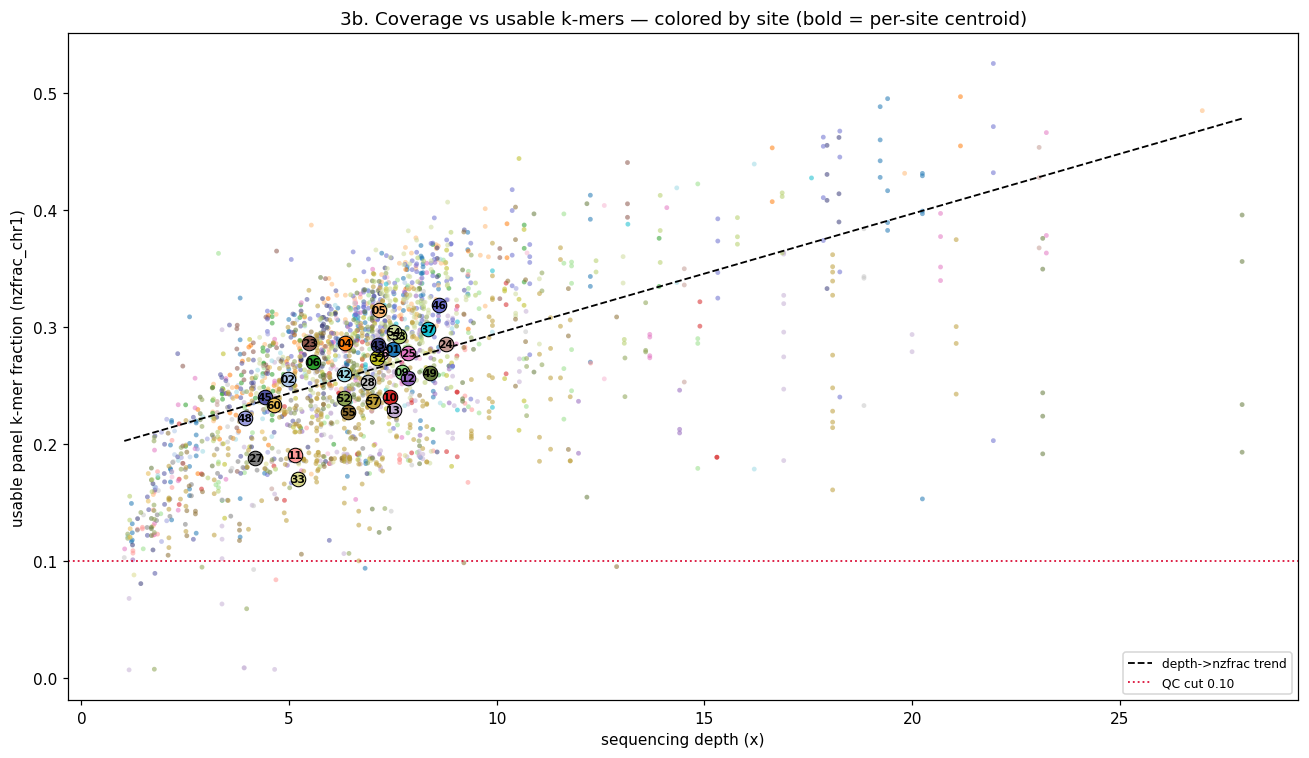

sites with the LOWEST mean usable-k-mer fraction:


,n,mean_depth,mean_nzfrac
site,,,
33,7,5.205,0.170
27,39,4.186,0.188
11,33,5.153,0.191
48,18,3.937,0.222
55,63,6.430,0.227
13,119,7.518,0.229
60,23,4.643,0.233
57,332,7.015,0.237


In [6]:
site = df.index.to_series().str[4:6]                     # MLFH<site><plot>...
sites = sorted(site.unique())
_pal = ([plt.cm.tab20(i) for i in range(20)] +
        [plt.cm.tab20b(i) for i in range(20)] + [plt.cm.tab20c(i) for i in range(20)])
cmap = {s: _pal[i % len(_pal)] for i, s in enumerate(sites)}
ok = df.seq_depth.notna() & df.nzfrac_chr1.notna()
fig, ax = plt.subplots(figsize=(12, 7))
for s in sites:
    m = (site == s) & ok
    ax.scatter(df.seq_depth[m], df.nzfrac_chr1[m], s=10, alpha=0.55,
               color=cmap[s], edgecolor='none')
# per-site centroids (labeled) so clustering is visible without a 40-entry legend
for s in sites:
    m = (site == s) & ok
    if m.sum() == 0: continue
    cx, cy = df.seq_depth[m].mean(), df.nzfrac_chr1[m].mean()
    ax.scatter([cx], [cy], s=90, color=cmap[s], edgecolor='k', lw=0.7, zorder=5)
    ax.annotate(s, (cx, cy), fontsize=7, fontweight='bold', zorder=6,
                ha='center', va='center')
xs = np.linspace(df.seq_depth.min(), df.seq_depth.max(), 100)
ax.plot(xs, slope * xs + intercept, 'k--', lw=1.2, label='depth->nzfrac trend')
ax.axhline(0.10, color='crimson', ls=':', lw=1.2, label='QC cut 0.10')
ax.set_xlabel('sequencing depth (x)')
ax.set_ylabel('usable panel k-mer fraction (nzfrac_chr1)')
ax.set_title('3b. Coverage vs usable k-mers — colored by site (bold = per-site centroid)')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout(); plt.show()

# quick numeric: which sites sit lowest on mean nzfrac
cen = df.assign(site=site.values).groupby('site').agg(
    n=('nzfrac_chr1','size'), mean_depth=('seq_depth','mean'),
    mean_nzfrac=('nzfrac_chr1','mean')).sort_values('mean_nzfrac')
print('sites with the LOWEST mean usable-k-mer fraction:')
display(cen.head(8).round(3))

## 3c. Same scatter — site 33 highlighted (the dropped low-usable-data site)

Site 33 (lowest mean nzfrac, dropped by the QC) in color; all other samples grey. Do site-33's
samples sit as a low group, or are they spread through the cloud?

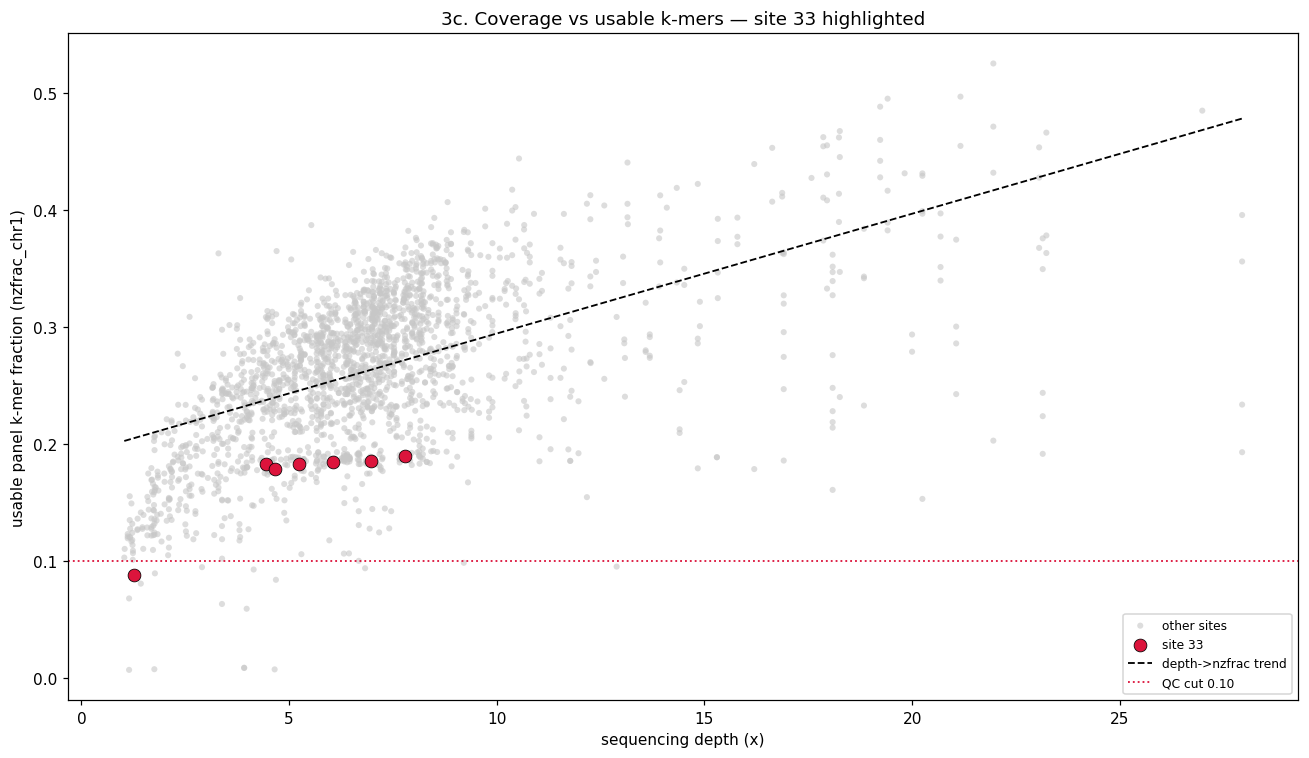

site 33: n=7  depth 1.3-7.8x  nzfrac 0.088-0.190  (#below 0.10 = 1)


In [7]:
site = df.index.to_series().str[4:6]
ok = df.seq_depth.notna() & df.nzfrac_chr1.notna()
is33 = (site == '33') & ok
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(df.seq_depth[ok & ~is33], df.nzfrac_chr1[ok & ~is33],
           s=16, color='0.78', alpha=0.6, edgecolor='none', label='other sites')
ax.scatter(df.seq_depth[is33], df.nzfrac_chr1[is33],
           s=70, color='crimson', edgecolor='k', lw=0.5, zorder=5, label='site 33')
xs = np.linspace(df.seq_depth.min(), df.seq_depth.max(), 100)
ax.plot(xs, slope * xs + intercept, 'k--', lw=1.2, label='depth->nzfrac trend')
ax.axhline(0.10, color='crimson', ls=':', lw=1.2, label='QC cut 0.10')
ax.set_xlabel('sequencing depth (x)')
ax.set_ylabel('usable panel k-mer fraction (nzfrac_chr1)')
ax.set_title('3c. Coverage vs usable k-mers — site 33 highlighted')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout(); plt.show()
print(f"site 33: n={int(is33.sum())}  depth {df.seq_depth[is33].min():.1f}-{df.seq_depth[is33].max():.1f}x  "
      f"nzfrac {df.nzfrac_chr1[is33].min():.3f}-{df.nzfrac_chr1[is33].max():.3f}  "
      f"(#below 0.10 = {int((df.nzfrac_chr1[is33]<0.10).sum())})")

## 4. The really-low samples — the 17 excluded, ranked

The 17 QC-excluded samples (`nzfrac < 0.10`), sorted by `nzfrac`. `residual` is
`nzfrac − trend-predicted(seq_depth)`. `contamination_suspect` flags samples whose depth is
normal-ish but whose nzfrac is anomalously low (strong negative residual) — i.e. the reads
just aren't from the panel. The 5 dead libraries are the clearest cases; the 0.06–0.10 band
is more of a *borderline low-usable-data* group.

In [8]:
excl_df = df.loc[df['excluded']].copy()

# contamination suspect: strongly negative residual (depth-adjusted nzfrac far too low)
# threshold = the dead cluster is clearly separated; use a residual cut that isolates
# the samples sitting well below trend. Base it on the residual distribution of kept samples.
kept_resid = df.loc[~df['excluded'], 'residual']
resid_cut = kept_resid.mean() - 3*kept_resid.std()   # >3 SD below the kept-sample trend
excl_df['contamination_suspect'] = (excl_df['residual'] < resid_cut) | excl_df.index.isin(dead_ids)

out = (excl_df.sort_values('nzfrac_chr1')
              [['seq_depth','nzfrac_chr1','pred_nzfrac','residual','contamination_suspect']]
              .round(4))
print(f"residual cut for 'contamination_suspect' (mean-3SD of kept): {resid_cut:.4f}")
print(f"n excluded = {len(out)}   |   n contamination_suspect = {int(out['contamination_suspect'].sum())}")
display(out)

print("\nPure contamination (normal depth, near-zero nzfrac):")
display(out[out['contamination_suspect']][['seq_depth','nzfrac_chr1','residual']])
print("Borderline low-usable-data (0.06-0.10 band, not flagged):")
display(out[~out['contamination_suspect']][['seq_depth','nzfrac_chr1','residual']])

residual cut for 'contamination_suspect' (mean-3SD of kept): -0.1625
n excluded = 17   |   n contamination_suspect = 10


,seq_depth,nzfrac_chr1,pred_nzfrac,residual,contamination_suspect
sample_id,,,,,
MLFH131020200221,1.1478,0.0069,0.2037,-0.1968,True
MLFH131220200205,4.6521,0.0073,0.2396,-0.2322,True
MLFH520720190322,1.7556,0.0075,0.2099,-0.2024,True
MLFH130820200221,3.9183,0.0085,0.2321,-0.2235,True
MLFH130820200205,3.9183,0.0088,0.2321,-0.2233,True
MLFH520120190322,3.9785,0.0592,0.2327,-0.1735,True
MLFH131120200221,3.3840,0.0632,0.2266,-0.1634,True
MLFH131020200205,1.1478,0.0680,0.2037,-0.1357,False
MLFH430120190228,1.4300,0.0806,0.2066,-0.1260,False



Pure contamination (normal depth, near-zero nzfrac):


,seq_depth,nzfrac_chr1,residual
sample_id,,,
MLFH131020200221,1.1478,0.0069,-0.1968
MLFH131220200205,4.6521,0.0073,-0.2322
MLFH520720190322,1.7556,0.0075,-0.2024
MLFH130820200221,3.9183,0.0085,-0.2235
MLFH130820200205,3.9183,0.0088,-0.2233
MLFH520120190322,3.9785,0.0592,-0.1735
MLFH131120200221,3.3840,0.0632,-0.1634
MLFH010320190401,6.8297,0.0938,-0.1681
MLFH550120180312,12.8855,0.0952,-0.2287


Borderline low-usable-data (0.06-0.10 band, not flagged):


,seq_depth,nzfrac_chr1,residual
sample_id,,,
MLFH131020200205,1.1478,0.0680,-0.1357
MLFH430120190228,1.4300,0.0806,-0.1260
MLFH110220180430,4.6827,0.0839,-0.1560
MLFH330120180607,1.2660,0.0880,-0.1169
MLFH450120190215,1.7694,0.0894,-0.1207
MLFH280220180305,4.1467,0.0927,-0.1417
MLFH520520190322,2.9032,0.0947,-0.1270


## 5. Summary

In [9]:
r_all = df.seq_depth.corr(df.nzfrac_chr1)
kept = df[~df['excluded']]
n_depth_lt2_usable = int((kept.seq_depth < 2).sum())
dead_depth = df.loc[dead_ids, 'seq_depth']
n_dead_above2 = int((dead_depth >= 2).sum())
print("SUMMARY")
print("-------")
print(f"* Depth alone is a poor QC signal: corr(depth, nzfrac) = {r_all:.2f}.")
print(f"* A depth<2x cut would drop ~{n_depth_lt2_usable} otherwise-usable samples")
print(f"  (nzfrac>=0.10) and STILL not isolate the dead cluster: {n_dead_above2}/5 dead")
print(f"  libraries have depth>=2x (up to {dead_depth.max():.1f}x).")
print(f"* nzfrac (usable panel k-mer fraction) cleanly separates the dead/contaminated")
print(f"  cluster (nzfrac<0.01, 5 samples) from the main body (starts ~0.06).")
print(f"* Cohort is QC-filtered at nzfrac<0.10 -> 17 samples dropped, {len(kept)} retained,")
print(f"  for all downstream analyses.")

SUMMARY
-------
* Depth alone is a poor QC signal: corr(depth, nzfrac) = 0.57.
* A depth<2x cut would drop ~72 otherwise-usable samples
  (nzfrac>=0.10) and STILL not isolate the dead cluster: 3/5 dead
  libraries have depth>=2x (up to 4.7x).
* nzfrac (usable panel k-mer fraction) cleanly separates the dead/contaminated
  cluster (nzfrac<0.01, 5 samples) from the main body (starts ~0.06).
* Cohort is QC-filtered at nzfrac<0.10 -> 17 samples dropped, 2151 retained,
  for all downstream analyses.


**Bottom line.**

- **Depth alone is a poor QC signal here** — `corr(depth, nzfrac) ≈ 0.57`. A naive
  `depth < 2×` cut would discard ~70 perfectly usable samples *and* still miss the dead
  libraries (most of them have depth ≥ 2×, up to ~4.7×).
- The **usable-panel-k-mer fraction (`nzfrac`)** cleanly separates the dead/contaminated
  cluster (`nzfrac < 0.01`, 5 samples) from the main body of the cohort.
- The cohort is therefore QC-filtered at **`nzfrac < 0.10` (17 samples dropped)** for all
  downstream work.
- **Contamination hypothesis:** the 5 dead libraries carry enough *sequencing* depth, but
  their k-mers are not from the 231 panel founders — pointing to contamination, a sample
  mislabel, or off-panel DNA rather than to shallow sequencing. This is exactly why they
  produced all-NaN founder `h`.